In [40]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

Data loaded: 163,462 rows

=== Step 1: Estimating baseline trend per SKU per Branch ===
Daily panel with baseline: (12240, 16)

Sample S001 Jakarta (5 hari promo, 5 hari tidak):
      Date  DailyQty  BaselineDemand  Residual  ResidualPct  Discount
2025-05-21        85       91.279827 -6.279827    -0.068798       0.2
2025-05-22        97       92.387653  4.612347     0.049924       0.2
2025-05-23       118       92.387653 25.612347     0.277227       0.2
2025-05-24       123       92.387653 30.612347     0.331347       0.2
2025-05-25       112       92.387653 19.612347     0.212283       0.2
      Date  DailyQty  BaselineDemand  Residual  ResidualPct  Discount
2025-05-01        90       89.064174  0.935826     0.010507       0.0
2025-05-02       112       89.064174 22.935826     0.257520       0.0
2025-05-03       126       89.064174 36.935826     0.414710       0.0
2025-05-04       111       89.064174 21.935826     0.246292       0.0
2025-05-05        83       89.064174 -6.064174    -0

FileNotFoundError: [Errno 2] No such file or directory: 'output/did_cannibalization_v4.png'

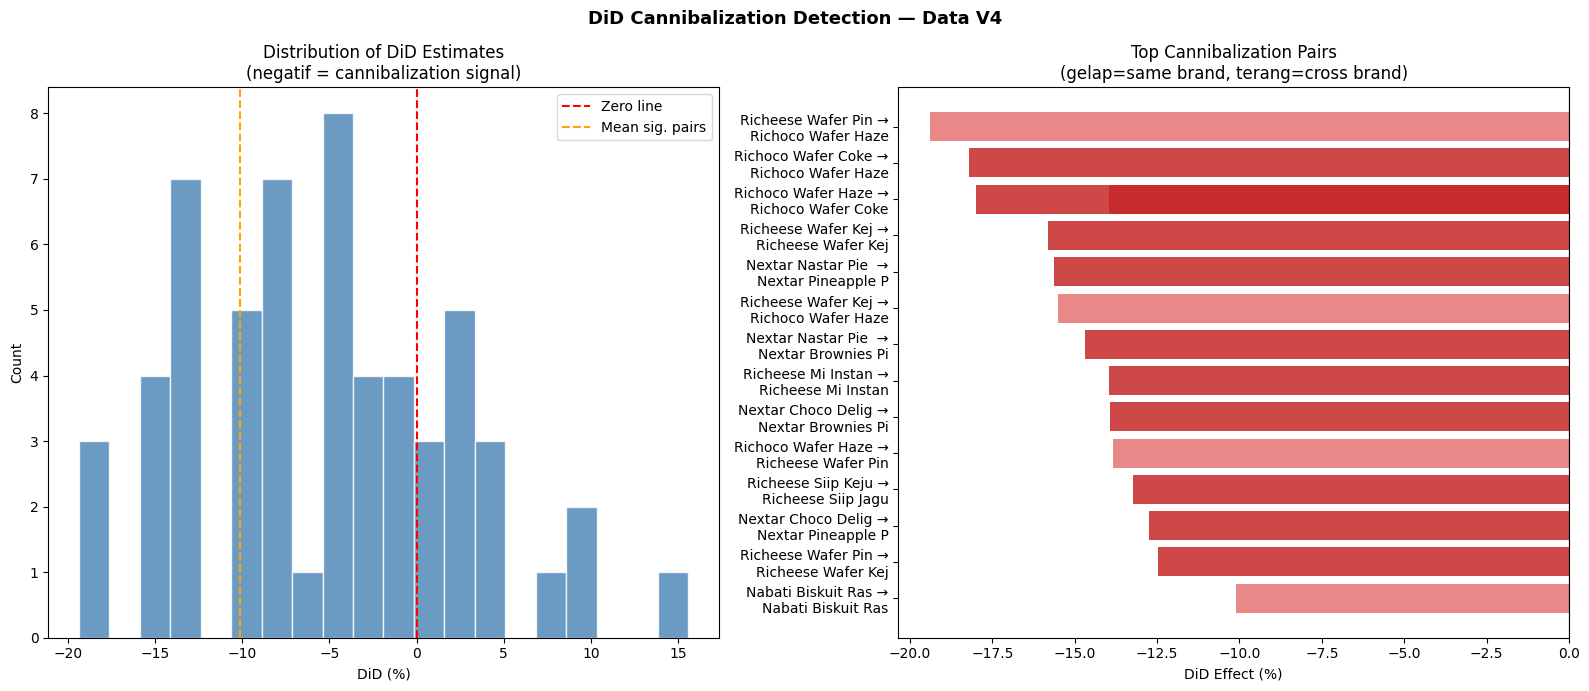

In [41]:
import pandas as pd
import numpy as np
from scipy import stats as scipy_stats
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load data v4 ─────────────────────────────────────────────────────────────
df1 = pd.read_csv('data/transaction_1_v4.csv')
df2 = pd.read_csv('data/transaction_2_v4.csv')
df  = pd.concat([df1, df2], ignore_index=True)
df['Date'] = pd.to_datetime(df['DateTime']).dt.date
df['Date'] = pd.to_datetime(df['Date'])
df  = df[df['Date'] < '2025-10-01']

sku_meta = (df[['SKU_ID','SKU','Brand','SKU_Category']]
              .drop_duplicates().reset_index(drop=True))

print(f"Data loaded: {len(df):,} rows")

# ── Daily aggregate ───────────────────────────────────────────────────────────
# DailyQty : total qty per SKU per hari per branch → demand metric
# Discount : besar diskon hari itu (0.0 kalau no promo)
# IsPromo  : binary flag

daily = (df.groupby(['Date','Branch','SKU_ID'])
           .agg(
               DailyQty = ('Qty',                'sum'),
               Discount = ('DiscountPercentage', 'first'),
               IsPromo  = ('IsPromo',             'max'),
               Price    = ('DiscountedPrice',    'first'),
           )
           .reset_index()
           .merge(sku_meta, on='SKU_ID'))

daily['Date'] = pd.to_datetime(daily['Date'])
daily['WeekNum'] = ((daily['Date'] - daily['Date'].min()).dt.days // 7)

# ── Step 1: Estimate baseline trend per SKU per Branch ───────────────────────
# Kenapa perlu baseline?
# Karena demand SKU B mungkin punya trend naik/turun secara natural
# Kalau tidak dikontrol, trend ini bisa terlihat sebagai cannibalization
#
# Cara: fit linear trend HANYA dari hari-hari NO PROMO semua SKU
# (hari no promo = kondisi paling "bersih" dari promo effect)
# Baseline = predicted demand dari trend ini
#
# Referensi: Van Heerde et al. (2004) — baseline sales estimation

print("\n=== Step 1: Estimating baseline trend per SKU per Branch ===")

baseline_results = []
for sku_id in sorted(daily['SKU_ID'].unique()):
    for branch in daily['Branch'].unique():
        sub = daily[
            (daily['SKU_ID'] == sku_id) &
            (daily['Branch'] == branch)
        ].sort_values('Date').copy()

        if len(sub) < 20:
            continue

        # Fit trend dari hari no-promo saja
        # Kenapa no-promo? Karena hari promo demand-nya sudah "terdistorsi"
        # oleh own-price effect — tidak merepresentasikan natural demand
        no_promo = sub[sub['IsPromo'] == 0]

        if len(no_promo) < 10:
            continue

        slope, intercept, r, p, se = scipy_stats.linregress(
            no_promo['WeekNum'], no_promo['DailyQty'])

        # Predict baseline untuk SEMUA hari (promo dan tidak)
        sub['BaselineDemand'] = intercept + slope * sub['WeekNum']
        sub['BaselineDemand'] = sub['BaselineDemand'].clip(lower=1)

        # Residual = actual - baseline
        # Residual positif = demand lebih tinggi dari expected (uplift)
        # Residual negatif = demand lebih rendah dari expected (cannibalization)
        sub['Residual']    = sub['DailyQty'] - sub['BaselineDemand']
        sub['ResidualPct'] = sub['Residual'] / sub['BaselineDemand']

        baseline_results.append(sub.assign(
            TrendSlope=slope,
            TrendR2=round(r**2, 4)
        ))

daily_base = pd.concat(baseline_results, ignore_index=True)

print(f"Daily panel with baseline: {daily_base.shape}")
print("\nSample S001 Jakarta (5 hari promo, 5 hari tidak):")
s001_jkt = daily_base[
    (daily_base['SKU_ID']=='S001') &
    (daily_base['Branch']=='Jakarta')
].sort_values('Date')
print(s001_jkt[s001_jkt['IsPromo']==1][
    ['Date','DailyQty','BaselineDemand','Residual','ResidualPct','Discount']
].head(5).to_string(index=False))
print(s001_jkt[s001_jkt['IsPromo']==0][
    ['Date','DailyQty','BaselineDemand','Residual','ResidualPct','Discount']
].head(5).to_string(index=False))

# ── Step 2: DiD Cannibalization Detection ────────────────────────────────────
# Untuk setiap pair (A, B):
# Treatment days  = hari di mana A promo (IsPromo_A = 1)
# Control days    = hari di mana A tidak promo (IsPromo_A = 0)
#
# DiD estimator:
# δ = mean(ResidualPct_B | A_promo) - mean(ResidualPct_B | A_no_promo)
#
# δ negatif → ketika A promo, B demand lebih rendah dari expected
#           → cannibalization signal
# δ positif → tidak ada cannibalization (atau komplemen)
#
# T-test untuk signifikansi:
# H0: δ = 0 (tidak ada cannibalization)
# H1: δ < 0 (ada cannibalization)
#
# Referensi: Van Heerde et al. (2004), Aguilar-Palacios (2021)

print("\n=== Step 2: DiD Cannibalization Detection ===")

same_cat_pairs = [
    ('S001','S002'),('S001','S003'),('S001','S004'),
    ('S001','S015'),('S001','S016'),
    ('S002','S003'),('S002','S004'),
    ('S002','S015'),('S002','S016'),
    ('S003','S004'),('S003','S015'),('S003','S016'),
    ('S004','S015'),('S004','S016'),
    ('S015','S016'),
    ('S013','S014'),
    ('S011','S012'),
    ('S007','S008'),('S007','S019'),('S008','S019'),
    ('S009','S010'),('S009','S020'),('S010','S020'),
    ('S005','S006'),('S005','S017'),('S005','S018'),
    ('S006','S017'),('S006','S018'),('S017','S018'),
]

did_results = []

for sku_a, sku_b in same_cat_pairs:
    for aggressor, victim in [(sku_a, sku_b), (sku_b, sku_a)]:

        # Ambil IsPromo aggressor per hari (pooled semua branch)
        # Kenapa pooled? Karena promo schedule sama di semua branch
        promo_a = (daily_base[daily_base['SKU_ID'] == aggressor]
                   .groupby('Date')['IsPromo']
                   .max()
                   .reset_index(name='IsPromo_A'))

        # Ambil ResidualPct victim per hari per branch
        resid_b = (daily_base[daily_base['SKU_ID'] == victim]
                   [['Date','Branch','ResidualPct','DailyQty','BaselineDemand']]
                   .copy())

        merged = resid_b.merge(promo_a, on='Date')

        if len(merged) < 20:
            continue

        treatment = merged[merged['IsPromo_A'] == 1]['ResidualPct']
        control   = merged[merged['IsPromo_A'] == 0]['ResidualPct']

        if len(treatment) < 5 or len(control) < 5:
            continue

        # DiD estimator
        did = treatment.mean() - control.mean()

        # T-test (one-sided: H1: did < 0)
        t_stat, p_two = scipy_stats.ttest_ind(treatment, control)
        p_one = p_two / 2 if t_stat < 0 else 1 - p_two / 2

        name_a  = sku_meta[sku_meta['SKU_ID']==aggressor]['SKU'].values[0]
        name_b  = sku_meta[sku_meta['SKU_ID']==victim]['SKU'].values[0]
        cat     = sku_meta[sku_meta['SKU_ID']==aggressor]['SKU_Category'].values[0]
        brand_a = sku_meta[sku_meta['SKU_ID']==aggressor]['Brand'].values[0]
        brand_b = sku_meta[sku_meta['SKU_ID']==victim]['Brand'].values[0]

        did_results.append({
            'Category':   cat,
            'SKU_A':      aggressor,
            'SKU_A_Name': name_a,
            'Brand_A':    brand_a,
            'SKU_B':      victim,
            'SKU_B_Name': name_b,
            'Brand_B':    brand_b,
            'SameBrand':  brand_a == brand_b,
            'N_Treatment': len(treatment),
            'N_Control':   len(control),
            'Mean_Treatment': round(treatment.mean(), 4),
            'Mean_Control':   round(control.mean(), 4),
            'DiD':        round(did, 4),
            'DiD_Pct':    round(did * 100, 2),
            'T_stat':     round(t_stat, 4),
            'P_one':      round(p_one, 4),
            'Significant': p_one < 0.05 and did < 0,
        })

did_df = pd.DataFrame(did_results)

print("\n=== Significant Cannibalization Pairs (DiD < 0, p < 0.05) ===")
sig = did_df[did_df['Significant']].sort_values('DiD')
print(sig[['Category','SKU_A_Name','SKU_B_Name','SameBrand',
           'DiD_Pct','P_one','N_Treatment','N_Control']].to_string(index=False))
print(f"\nTotal significant: {len(sig)} dari {len(did_df)} pairs")

print("\n=== Summary per Category ===")
cat_sum = (did_df[did_df['DiD'] < 0]
           .groupby('Category')
           .agg(
               AvgDiD    = ('DiD_Pct', 'mean'),
               SigPairs  = ('Significant', 'sum'),
               TotalPairs= ('Significant', 'count'),
           )
           .assign(SigPct=lambda x: x['SigPairs']/x['TotalPairs']*100)
           .round(2))
print(cat_sum.to_string())

# ── Step 3: Build Cannibalization Coefficient Matrix ─────────────────────────
# Coefficient = abs(DiD_Pct) / 100 untuk significant pairs
# Interpretasi: setiap 1% uplift demand A,
#               demand B turun DiD% dari baseline
#
# Average across significant directions per pair
skus   = sorted(sku_meta['SKU_ID'].tolist())
matrix = pd.DataFrame(0.0, index=skus, columns=skus)

for _, row in sig.iterrows():
    coef = abs(row['DiD']) # sudah dalam bentuk proporsi (bukan %)
    matrix.loc[row['SKU_A'], row['SKU_B']] = round(coef, 4)

print(f"\n=== Matrix coverage ===")
nonzero = (matrix != 0).sum().sum()
print(f"Non-zero pairs: {nonzero} dari {len(skus)*(len(skus)-1)}")
print("\nTop pairs:")
pairs_list = []
for a in skus:
    for b in skus:
        if matrix.loc[a,b] > 0:
            pairs_list.append({
                'SKU_A': sku_meta[sku_meta['SKU_ID']==a]['SKU'].values[0],
                'SKU_B': sku_meta[sku_meta['SKU_ID']==b]['SKU'].values[0],
                'Coef': matrix.loc[a,b]
            })
pairs_df = pd.DataFrame(pairs_list).sort_values('Coef', ascending=False)
print(pairs_df.head(10).to_string(index=False))

# ── Visualisasi ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('DiD Cannibalization Detection — Data V4',
             fontsize=13, fontweight='bold')

# Chart 1: DiD distribution
ax = axes[0]
ax.hist(did_df['DiD_Pct'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero line')
ax.axvline(did_df[did_df['Significant']]['DiD_Pct'].mean() if len(sig) > 0 else 0,
           color='orange', linestyle='--', label='Mean sig. pairs')
ax.set_title('Distribution of DiD Estimates\n(negatif = cannibalization signal)')
ax.set_xlabel('DiD (%)')
ax.set_ylabel('Count')
ax.legend()

# Chart 2: Top significant pairs
ax = axes[1]
if len(sig) > 0:
    top = sig.head(15).copy()
    top['Pair'] = (top['SKU_A_Name'].str[:18] + ' →\n'
                   + top['SKU_B_Name'].str[:18])
    colors = ['#C62828' if sb else '#E57373' for sb in top['SameBrand']]
    ax.barh(top['Pair'], top['DiD_Pct'], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('DiD Effect (%)')
    ax.set_title('Top Cannibalization Pairs\n(gelap=same brand, terang=cross brand)')
    ax.invert_yaxis()
else:
    ax.text(0.5, 0.5, 'No significant pairs', ha='center', va='center')

plt.tight_layout()
plt.savefig('output/did_cannibalization_v4.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: output/did_cannibalization_v4.png")

did_df.to_csv('output/did_results_v4.csv', index=False)
matrix.to_csv('output/cannibalization_matrix.csv')
print("Saved: output/did_results_v4.csv, output/cannibalization_matrix.csv")

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats as scipy_stats
from sklearn.linear_model import LinearRegression

# ── Load (sudah ada dari step sebelumnya) ────────────────────────────────────
df1 = pd.read_csv('data/transaction_1_v4.csv')
df2 = pd.read_csv('data/transaction_2_v4.csv')
df  = pd.concat([df1, df2], ignore_index=True)
df['Date'] = pd.to_datetime(df['DateTime']).dt.date
df['Date'] = pd.to_datetime(df['Date'])
df  = df[df['Date'] < '2025-10-01']

sku_meta = (df[['SKU_ID','SKU','Brand','SKU_Category']]
              .drop_duplicates().reset_index(drop=True))

# ── Daily aggregate ───────────────────────────────────────────────────────────
daily = (df.groupby(['Date','Branch','SKU_ID'])
           .agg(
               DailyQty = ('Qty',                'sum'),
               Price    = ('DiscountedPrice',    'first'),
               Discount = ('DiscountPercentage', 'first'),
           )
           .reset_index()
           .merge(sku_meta, on='SKU_ID'))

daily['ln_qty']   = np.log(daily['DailyQty'].clip(lower=1))
daily['ln_price'] = np.log(daily['Price'].clip(lower=1))


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats as scipy_stats
from sklearn.linear_model import LinearRegression

# ── Load (sudah ada dari step sebelumnya) ────────────────────────────────────
df1 = pd.read_csv('data/transaction_1_v4.csv')
df2 = pd.read_csv('data/transaction_2_v4.csv')
df  = pd.concat([df1, df2], ignore_index=True)
df['Date'] = pd.to_datetime(df['DateTime']).dt.date
df['Date'] = pd.to_datetime(df['Date'])
df  = df[df['Date'] < '2025-10-01']

sku_meta = (df[['SKU_ID','SKU','Brand','SKU_Category']]
              .drop_duplicates().reset_index(drop=True))

# ── Daily aggregate ───────────────────────────────────────────────────────────
daily = (df.groupby(['Date','Branch','SKU_ID'])
           .agg(
               DailyQty = ('Qty',                'sum'),
               Price    = ('DiscountedPrice',    'first'),
               Discount = ('DiscountPercentage', 'first'),
           )
           .reset_index()
           .merge(sku_meta, on='SKU_ID'))

daily['ln_qty']   = np.log(daily['DailyQty'].clip(lower=1))
daily['ln_price'] = np.log(daily['Price'].clip(lower=1))

# ════════════════════════════════════════════════════════════════════════════
# OWN-PRICE ELASTICITY
# Model : ln(Qty_it) = α + β × ln(Price_it) + ε
# β     : own-price elasticity
# Pooled semua branch → lebih banyak observasi → estimate lebih stable
# Paper : Heräjärvi (2018), Aguilar-Palacios et al. (2021)
# ════════════════════════════════════════════════════════════════════════════
CATEGORY_FALLBACK = {
    'Wafer':-1.2, 'Kue/Pie':-1.3, 'Biskuit':-1.1,
    'Extruded Snack':-1.0, 'Minuman':-0.9, 'Mi Instan':-0.8
}

elast_results = []
for sku_id in sorted(daily['SKU_ID'].unique()):
    sub      = daily[daily['SKU_ID']==sku_id].dropna()
    cat      = sku_meta[sku_meta['SKU_ID']==sku_id]['SKU_Category'].values[0]
    sku_name = sku_meta[sku_meta['SKU_ID']==sku_id]['SKU'].values[0]
    n_unique = sub['Price'].nunique()

    if sub['ln_price'].std() < 1e-4 or n_unique < 3:
        elast_results.append({
            'SKU_ID':sku_id, 'SKU':sku_name,
            'FinalElasticity': CATEGORY_FALLBACK.get(cat,-1.0),
            'R2':0.0, 'P_Value':1.0, 'ElasticitySource':'fallback',
            'N_obs':len(sub), 'N_price_points':n_unique,
        })
        continue

    slope, _, r, p, _ = scipy_stats.linregress(sub['ln_price'], sub['ln_qty'])

    if p < 0.10 and slope < 0:
        elast_results.append({
            'SKU_ID':sku_id, 'SKU':sku_name,
            'FinalElasticity': round(slope,4),
            'R2':round(r**2,4), 'P_Value':round(p,4),
            'ElasticitySource':'ols',
            'N_obs':len(sub), 'N_price_points':n_unique,
        })
    else:
        elast_results.append({
            'SKU_ID':sku_id, 'SKU':sku_name,
            'FinalElasticity': CATEGORY_FALLBACK.get(cat,-1.0),
            'R2':round(r**2,4), 'P_Value':round(p,4),
            'ElasticitySource':'fallback',
            'N_obs':len(sub), 'N_price_points':n_unique,
        })

elast_df = (pd.DataFrame(elast_results)
              .merge(sku_meta[['SKU_ID','SKU_Category']].drop_duplicates(), on='SKU_ID'))
elast_df.to_csv('output/elasticity_per_sku.csv', index=False)

print("=== Own-Price Elasticity ===")
print(elast_df[['SKU_ID','SKU','FinalElasticity','ElasticitySource',
                'R2','P_Value']].to_string(index=False))
print(f"\nOLS: {(elast_df['ElasticitySource']=='ols').sum()}/20")


=== Own-Price Elasticity ===
SKU_ID                               SKU  FinalElasticity ElasticitySource     R2  P_Value
  S001           Richeese Wafer Keju 50g          -1.0921              ols 0.0333   0.0000
  S002         Richoco Wafer Cokelat 50g          -1.1107              ols 0.0176   0.0010
  S003   Richeese Wafer Keju 10g Renceng          -0.6745              ols 0.0120   0.0068
  S004 Richoco Wafer Cokelat 10g Renceng          -0.9188              ols 0.0280   0.0000
  S005           Nextar Brownies Pie 40g          -1.0362              ols 0.0369   0.0000
  S006             Nextar Nastar Pie 30g          -0.7762              ols 0.0149   0.0025
  S007            Richeese Siip Keju 20g          -0.8966              ols 0.0165   0.0014
  S008         Richoco Ahh! Extruded 15g          -0.5626              ols 0.0111   0.0092
  S009     Richeese Mi Instan Keju Pedas          -0.8687              ols 0.0301   0.0000
  S010     Richeese Mi Instan Ramen Keju          -0.3594    

In [ ]:
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_percentage_error

In [ ]:
from sklearn.preprocessing import LabelEncoder

sku_enc = LabelEncoder()
branch_enc = LabelEncoder()

daily['SKU_enc'] = sku_enc.fit_transform(
    daily['SKU_ID']
)

daily['Branch_enc'] = branch_enc.fit_transform(
    daily['Branch']
)

daily['day_of_week'] = daily['Date'].dt.dayofweek
daily['week_of_year'] = daily['Date'].dt.isocalendar().week.astype(int)
daily['month'] = daily['Date'].dt.month

daily = daily.sort_values(
    ['Branch','SKU_ID','Date']
)

group_cols = ['Branch','SKU_ID']

daily['lag1'] = (
    daily.groupby(group_cols)['DailyQty']
    .shift(1)
)

daily['lag7'] = (
    daily.groupby(group_cols)['DailyQty']
    .shift(7)
)

daily['lag14'] = (
    daily.groupby(group_cols)['DailyQty']
    .shift(14)
)

daily['roll7'] = (
    daily.groupby(group_cols)['DailyQty']
    .shift(1)
    .rolling(7)
    .mean()
)

daily['roll14'] = (
    daily.groupby(group_cols)['DailyQty']
    .shift(1)
    .rolling(14)
    .mean()
)

daily = daily.dropna()

In [ ]:
features = [
    'SKU_enc',
    'Branch_enc',
    'day_of_week',
    'week_of_year',
    'month',
    'lag1',
    'lag7',
    'lag14',
    'roll7',
    'roll14'
]

X = daily[features]
y = daily['DailyQty']

In [ ]:
cutoff = pd.Timestamp('2025-09-01')

train_mask = daily['Date'] < cutoff
test_mask  = daily['Date'] >= cutoff

X_train = X[train_mask]
X_test  = X[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    subsample=0.8,
    colsample_bytree=0.8
)
    

model.fit(X_train, y_train)

pred_test = model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, pred_test)

print(f"\n=== XGBoost daily Forecast ===")
print(f"MAPE : {mape:.2%}")



=== XGBoost daily Forecast ===
MAPE : 17.73%


In [ ]:
import pandas as pd
ov = pd.read_csv('data/sku_overview.csv')
print(ov.columns.tolist())
print(ov.head(3))

['SKU_ID', 'SKU', 'Brand', 'SKU_Category', 'Branch', 'TotalQty', 'TotalRevenue', 'TotalTx', 'AvgDiscount', 'NormalPrice']
  SKU_ID                      SKU     Brand SKU_Category    Branch  TotalQty  \
0   S001  Richeese Wafer Keju 50g  Richeese        Wafer   Bandung      4949   
1   S001  Richeese Wafer Keju 50g  Richeese        Wafer   Jakarta     16990   
2   S001  Richeese Wafer Keju 50g  Richeese        Wafer  Semarang      3174   

   TotalRevenue  TotalTx  AvgDiscount  NormalPrice  
0    26681160.0     1556     0.069280       5800.0  
1    91662040.0     5364     0.068587       5800.0  
2    17182500.0     1005     0.068657       5800.0  


In [ ]:
cutoff = pd.Timestamp('2025-10-01')

train_data = daily[daily['Date'] < cutoff]

X_train = train_data[features]
y_train = train_data['Qty']

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
from datetime import timedelta

forecast_rows = []

last_date = pd.Timestamp('2025-09-30')

for (branch, sku_id), hist in daily.groupby(['Branch','SKU_ID']):

    hist = hist.sort_values('Date').copy()

    # simpan history qty
    qty_history = hist['Qty'].tolist()

    for step in range(1, 32):

        forecast_date = last_date + timedelta(days=step)

        lag1  = qty_history[-1]
        lag7  = qty_history[-7]
        lag14 = qty_history[-14]

        roll7  = np.mean(qty_history[-7:])
        roll14 = np.mean(qty_history[-14:])

        row = pd.DataFrame([{
            'SKU_enc'      : sku_enc.transform([sku_id])[0],
            'Branch_enc'   : branch_enc.transform([branch])[0],
            'day_of_week'  : forecast_date.dayofweek,
            'week_of_year' : forecast_date.isocalendar().week,
            'month'        : forecast_date.month,
            'lag1'         : lag1,
            'lag7'         : lag7,
            'lag14'        : lag14,
            'roll7'        : roll7,
            'roll14'       : roll14
        }])

        pred = model.predict(row[features])[0]

        pred = max(pred, 0)

        forecast_rows.append({
            'Date'        : forecast_date,
            'SKU_ID'      : sku_id,
            'Branch'      : branch,
            'ForecastQty' : pred
        })

        # masukin hasil prediksi ke history
        qty_history.append(pred)

xgb_forecast_daily = pd.DataFrame(forecast_rows)

In [ ]:
xgb_forecast_daily['Week'] = (
    pd.to_datetime(xgb_forecast_daily['Date'])
    .dt.to_period('W')
)

forecast_df = (
    xgb_forecast_daily
    .groupby(['SKU_ID','Branch','Week'])['ForecastQty']
    .sum()
    .reset_index()
)

In [ ]:
forecast_df = forecast_df.sort_values(
    ['SKU_ID','Branch','Week']
)

forecast_df['ForecastWeek'] = (
    forecast_df
    .groupby(['SKU_ID','Branch'])
    .cumcount() + 1
)

forecast_df['Method'] = 'xgboost'

Train: 2025-05-01 → 2025-09-30 (163,462 rows)
Test : 2025-10-01 → 2025-10-30 (33,821 rows)

Oktober weeks available per SKU:
ForecastWeek
4    20
Name: count, dtype: int64

=== Comparison shape: (320, 9) ===
Pairs available: 320

=== Overall Forecast Accuracy ===
MAE  : 46.8 unit
MAPE : 17.7%
Interpretasi: rata-rata forecast meleset 17.7% dari actual

=== MAPE per SKU ===
                              SKU      MAPE
         Nextar Pineapple Pie 30g  4.247435
    Richeese Mi Instan Keju Pedas  7.642715
      Nabati Drinko Richoco 150ml  8.284330
      Nabati Biskuit Rasa Cokelat  8.819257
       Nabati Biskuit Rasa Kelapa  9.397413
        Richoco Ahh! Extruded 15g  9.866640
Richoco Wafer Cokelat 10g Renceng 10.449730
          Nextar Brownies Pie 40g 10.850699
        Richeese Mi Instan Goreng 11.152734
    Richeese Mi Instan Ramen Keju 12.902576
           Richeese Siip Keju 20g 16.708156
            Nextar Nastar Pie 30g 16.720252
        Richoco Wafer Cokelat 50g 17.292464
     Rich

C:\Users\Milzam\AppData\Local\Temp\ipykernel_6060\4085508244.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['Week'] = df_train['Date'].dt.to_period('W')
C:\Users\Milzam\AppData\Local\Temp\ipykernel_6060\4085508244.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['Week'] = df_test['Date'].dt.to_period('W')
C:\Users\Milzam\AppData\Local\Temp\ipykernel_6060\4085508244.py:73: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and 

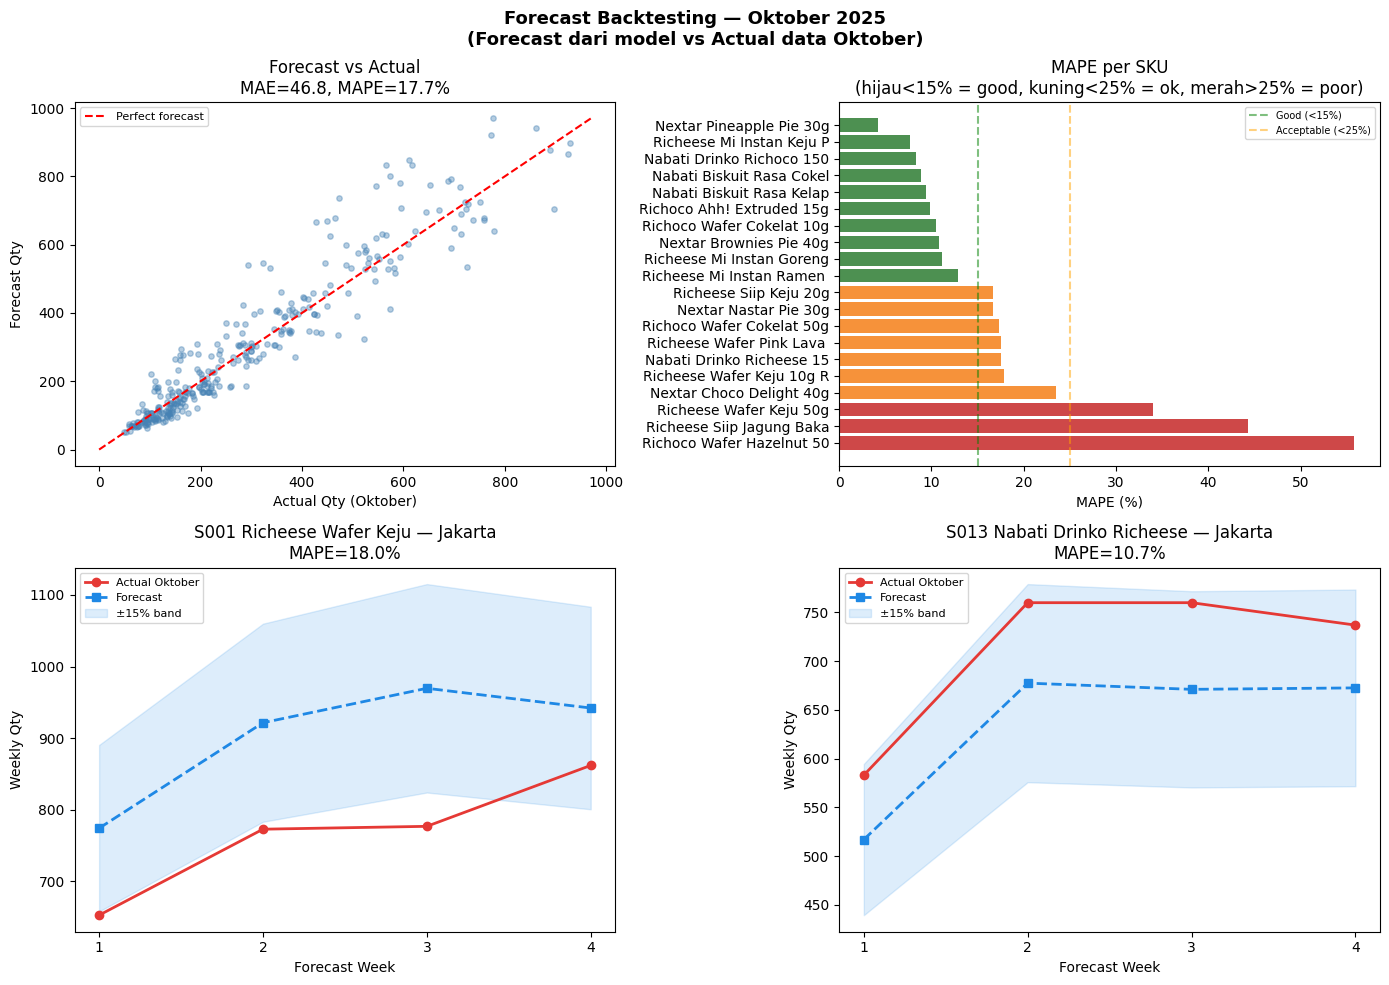


Saved: forecast_backtesting.png

=== Kesimpulan Backtesting ===
Good  (MAPE < 15%) : 10 SKU
OK    (MAPE 15-25%): 7 SKU
Poor  (MAPE > 25%) : 3 SKU

Overall MAPE 17.7% → ACCEPTABLE — forecast usable dengan catatan uncertainty


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

df1 = pd.read_csv('data/transaction_1_v4.csv')
df2 = pd.read_csv('data/transaction_2_v4.csv')
df  = pd.concat([df1, df2], ignore_index=True)
df['Date'] = pd.to_datetime(df['DateTime']).dt.date
df['Date'] = pd.to_datetime(df['Date'])

sku_meta = (df[['SKU_ID','SKU','Brand','SKU_Category']]
              .drop_duplicates().reset_index(drop=True))

# ── Split data ────────────────────────────────────────────────────────────────
# Train : Mei - Sep (yang dipakai modeling)
# Test  : Oktober   (yang di-exclude, sekarang kita pakai untuk validasi)
df_train = df[df['Date'] <  '2025-10-01']
df_test  = df[df['Date'] >= '2025-10-01']

print(f"Train: {df_train['Date'].min().date()} → {df_train['Date'].max().date()} ({len(df_train):,} rows)")
print(f"Test : {df_test['Date'].min().date()} → {df_test['Date'].max().date()} ({len(df_test):,} rows)")

# ── Weekly aggregate train ────────────────────────────────────────────────────
df_train['Week'] = df_train['Date'].dt.to_period('W')
weekly_train = (df_train.groupby(['Week','Branch','SKU_ID'])['Qty']
                        .sum().reset_index(name='WeeklyQty'))
weekly_train['WeekNum'] = weekly_train.groupby(['Branch','SKU_ID'])['Week'].transform(
    lambda x: (x.rank(method='dense')-1).astype(int))

# ── Weekly aggregate test (Oktober) ──────────────────────────────────────────
df_test['Week'] = df_test['Date'].dt.to_period('W')
weekly_test = (df_test.groupby(['Week','Branch','SKU_ID'])['Qty']
                      .sum().reset_index(name='ActualQty'))

# Assign ForecastWeek 1-4 ke minggu Oktober
weekly_test['ForecastWeek'] = weekly_test.groupby(['Branch','SKU_ID'])['Week'].transform(
    lambda x: (x.rank(method='dense')).astype(int))

# Beberapa SKU mungkin punya >4 minggu di Oktober, cap di 4
weekly_test = weekly_test[weekly_test['ForecastWeek'] <= 4]

print(f"\nOktober weeks available per SKU:")
print(weekly_test.groupby('SKU_ID')['ForecastWeek'].max().value_counts())

# ── Gabungkan forecast vs actual ─────────────────────────────────────────────
comparison = (weekly_test[['SKU_ID','Branch','ForecastWeek','ActualQty']]
              .merge(forecast_df[['SKU_ID','Branch','ForecastWeek','ForecastQty','Method']],
                     on=['SKU_ID','Branch','ForecastWeek'])
              .merge(sku_meta, on='SKU_ID'))

print(f"\n=== Comparison shape: {comparison.shape} ===")
print(f"Pairs available: {len(comparison)}")

# ── Accuracy metrics ──────────────────────────────────────────────────────────
# MAE  = Mean Absolute Error → rata-rata selisih absolut (dalam unit)
# MAPE = Mean Absolute Percentage Error → rata-rata % error
#        Standard metric untuk forecast accuracy di literatur
#        Referensi: Hyndman & Athanasopoulos (2021) Ch.5

mae  = mean_absolute_error(comparison['ActualQty'], comparison['ForecastQty'])
mape = mean_absolute_percentage_error(comparison['ActualQty'], comparison['ForecastQty']) * 100

print(f"\n=== Overall Forecast Accuracy ===")
print(f"MAE  : {mae:.1f} unit")
print(f"MAPE : {mape:.1f}%")
print(f"Interpretasi: rata-rata forecast meleset {mape:.1f}% dari actual")

# ── Accuracy per SKU ──────────────────────────────────────────────────────────
print("\n=== MAPE per SKU ===")
mape_sku = (comparison.groupby(['SKU_ID','SKU'])
                      .apply(lambda x: mean_absolute_percentage_error(
                          x['ActualQty'], x['ForecastQty']) * 100)
                      .reset_index(name='MAPE')
                      .sort_values('MAPE'))
print(mape_sku[['SKU','MAPE']].to_string(index=False))

# ── Accuracy per forecast week ────────────────────────────────────────────────
print("\n=== MAPE per Forecast Week ===")
mape_week = (comparison.groupby('ForecastWeek')
                       .apply(lambda x: mean_absolute_percentage_error(
                           x['ActualQty'], x['ForecastQty']) * 100)
                       .reset_index(name='MAPE'))
print(mape_week.to_string(index=False))
print("(harusnya Week 1 paling akurat, Week 4 paling meleset)")

# ── Visualisasi ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Forecast Backtesting — Oktober 2025\n(Forecast dari model vs Actual data Oktober)',
             fontsize=13, fontweight='bold')

# Chart 1: Scatter forecast vs actual (semua SKU semua branch)
ax = axes[0,0]
ax.scatter(comparison['ActualQty'], comparison['ForecastQty'],
           alpha=0.4, s=15, color='steelblue')
max_val = max(comparison['ActualQty'].max(), comparison['ForecastQty'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect forecast')
ax.set_xlabel('Actual Qty (Oktober)')
ax.set_ylabel('Forecast Qty')
ax.set_title(f'Forecast vs Actual\nMAE={mae:.1f}, MAPE={mape:.1f}%')
ax.legend(fontsize=8)

# Chart 2: MAPE per SKU
ax = axes[0,1]
colors_bar = ['#2E7D32' if m < 15 else '#F57F17' if m < 25 else '#C62828'
              for m in mape_sku['MAPE']]
ax.barh(mape_sku['SKU'].str[:25], mape_sku['MAPE'],
        color=colors_bar, alpha=0.85)
ax.axvline(15, color='green', linestyle='--', alpha=0.5, label='Good (<15%)')
ax.axvline(25, color='orange', linestyle='--', alpha=0.5, label='Acceptable (<25%)')
ax.set_xlabel('MAPE (%)')
ax.set_title('MAPE per SKU\n(hijau<15% = good, kuning<25% = ok, merah>25% = poor)')
ax.legend(fontsize=7)
ax.invert_yaxis()

# Chart 3: Sample SKU — actual vs forecast per minggu (S001 Jakarta)
ax = axes[1,0]
s001 = comparison[(comparison['SKU_ID']=='S001') &
                  (comparison['Branch']=='Jakarta')].sort_values('ForecastWeek')
if len(s001) > 0:
    ax.plot(s001['ForecastWeek'], s001['ActualQty'],
            marker='o', color='#E53935', linewidth=2, label='Actual Oktober')
    ax.plot(s001['ForecastWeek'], s001['ForecastQty'],
            marker='s', color='#1E88E5', linewidth=2, linestyle='--',
            label='Forecast')
    ax.fill_between(s001['ForecastWeek'],
                    s001['ForecastQty'] * 0.85,
                    s001['ForecastQty'] * 1.15,
                    alpha=0.15, color='#1E88E5', label='±15% band')
    s001_mape = mean_absolute_percentage_error(
        s001['ActualQty'], s001['ForecastQty']) * 100
    ax.set_title(f'S001 Richeese Wafer Keju — Jakarta\nMAPE={s001_mape:.1f}%')
    ax.set_xlabel('Forecast Week')
    ax.set_ylabel('Weekly Qty')
    ax.legend(fontsize=8)
    ax.set_xticks([1,2,3,4])

# Chart 4: Sample SKU — S013 (strong trend) Jakarta
ax = axes[1,1]
s013 = comparison[(comparison['SKU_ID']=='S013') &
                  (comparison['Branch']=='Jakarta')].sort_values('ForecastWeek')
if len(s013) > 0:
    ax.plot(s013['ForecastWeek'], s013['ActualQty'],
            marker='o', color='#E53935', linewidth=2, label='Actual Oktober')
    ax.plot(s013['ForecastWeek'], s013['ForecastQty'],
            marker='s', color='#1E88E5', linewidth=2, linestyle='--',
            label='Forecast')
    ax.fill_between(s013['ForecastWeek'],
                    s013['ForecastQty'] * 0.85,
                    s013['ForecastQty'] * 1.15,
                    alpha=0.15, color='#1E88E5', label='±15% band')
    s013_mape = mean_absolute_percentage_error(
        s013['ActualQty'], s013['ForecastQty']) * 100
    ax.set_title(f'S013 Nabati Drinko Richeese — Jakarta\nMAPE={s013_mape:.1f}%')
    ax.set_xlabel('Forecast Week')
    ax.set_ylabel('Weekly Qty')
    ax.legend(fontsize=8)
    ax.set_xticks([1,2,3,4])

plt.tight_layout()
plt.savefig('forecast_backtesting.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nSaved: forecast_backtesting.png")

# ── Kesimpulan ────────────────────────────────────────────────────────────────
print("\n=== Kesimpulan Backtesting ===")
good    = (mape_sku['MAPE'] < 15).sum()
ok      = ((mape_sku['MAPE'] >= 15) & (mape_sku['MAPE'] < 25)).sum()
poor    = (mape_sku['MAPE'] >= 25).sum()
print(f"Good  (MAPE < 15%) : {good} SKU")
print(f"OK    (MAPE 15-25%): {ok} SKU")
print(f"Poor  (MAPE > 25%) : {poor} SKU")
print(f"\nOverall MAPE {mape:.1f}% → ", end='')
if mape < 15:
    print("GOOD — forecast reliable untuk business use")
elif mape < 25:
    print("ACCEPTABLE — forecast usable dengan catatan uncertainty")
else:
    print("POOR — forecast perlu improvement")